In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
import seaborn as sns

In [26]:
x,y = make_moons(n_samples=1000,noise=0.2)

In [27]:
df = {"x1":x[:,0],"x2":x[:,1],"y":y}

In [28]:
dataset = pd.DataFrame(df)

In [29]:
dataset

,x1,x2,y
0,-0.379261,0.966568,0
1,1.714717,-0.132695,1
2,-1.193648,0.260412,0
3,1.349502,-0.720539,1
4,0.472309,-0.340811,1
...,...,...,...
995,1.744933,0.413611,1
996,-0.954321,0.031978,0
997,-0.994856,0.083492,0
998,0.916999,-0.827684,1


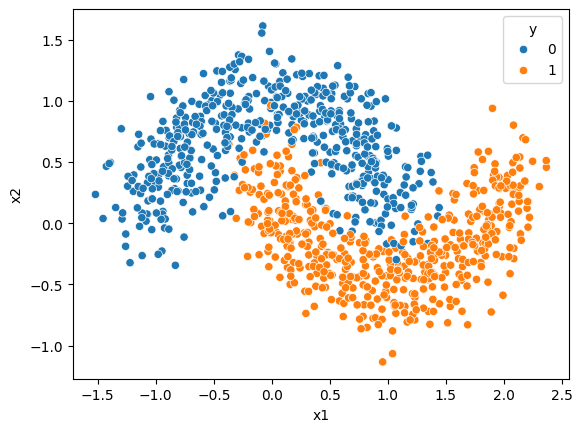

In [30]:
sns.scatterplot(x="x1",y="x2",data=dataset,hue="y")
plt.show()

In [31]:
x_a = dataset.iloc[:,:-1]
x_a

,x1,x2
0,-0.379261,0.966568
1,1.714717,-0.132695
2,-1.193648,0.260412
3,1.349502,-0.720539
4,0.472309,-0.340811
...,...,...
995,1.744933,0.413611
996,-0.954321,0.031978
997,-0.994856,0.083492
998,0.916999,-0.827684


In [32]:
x_a = dataset.iloc[:,:-1]
y_a = dataset["y"]

In [33]:
from sklearn.model_selection import train_test_split

In [34]:
x_train , x_test , y_train , y_test = train_test_split(x_a,y_a,test_size=0.2,random_state=42)

In [36]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

In [37]:
dt = DecisionTreeClassifier()
dt.fit(x_train,y_train)
dt.score(x_train,y_train)*100 , dt.score(x_test,y_test)*100

(100.0, 96.0)

In [39]:
sv = SVC()
sv.fit(x_train,y_train)
sv.score(x_train,y_train)*100 , sv.score(x_test,y_test)*100

(96.25, 96.0)

In [41]:
gnb = DecisionTreeClassifier()
gnb.fit(x_train,y_train)
gnb.score(x_train,y_train)*100 , gnb.score(x_test,y_test)*100

(100.0, 96.5)

In [42]:
from sklearn.ensemble import VotingClassifier

In [43]:
li = [("dt1",DecisionTreeClassifier()),("sv1",SVC()),("gnb1",GaussianNB())]

In [49]:
vc = VotingClassifier(li,weights=[10,4,7])
vc.fit(x_train,y_train)

VotingClassifier(estimators=[('dt1', DecisionTreeClassifier()), ('sv1', SVC()),
                             ('gnb1', GaussianNB())],
                 weights=[10, 4, 7])

In [50]:
vc.score(x_train,y_train)*100 , vc.score(x_test,y_test)*100

(96.75, 95.5)

In [51]:
prd = {"dt":dt.predict(x_test),"svm":sv.predict(x_test),"gnb":gnb.predict(x_test),"vc":vc.predict(x_test)}

In [52]:
pd.DataFrame(prd)

,dt,svm,gnb,vc
0,0,0,0,0
1,1,1,1,1
2,0,0,0,0
3,1,1,1,1
4,0,0,0,0
...,...,...,...,...
195,0,0,0,0
196,0,0,0,0
197,0,0,0,0
198,0,0,0,0
